In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [21]:
df = pd.DataFrame([
    {"Location":"Najafgarh","NDVI":0.10,"NO2":0.00009,"Temperature":41},
    {"Location":"Bawana","NDVI":0.06,"NO2":0.00010,"Temperature":46},
    {"Location":"Okhla","NDVI":0.37,"NO2":0.00013,"Temperature":43},
    {"Location":"Palam","NDVI":0.02,"NO2":0.00012,"Temperature":38},
    {"Location":"Badarpur","NDVI":0.34,"NO2":0.00013,"Temperature":44},
])

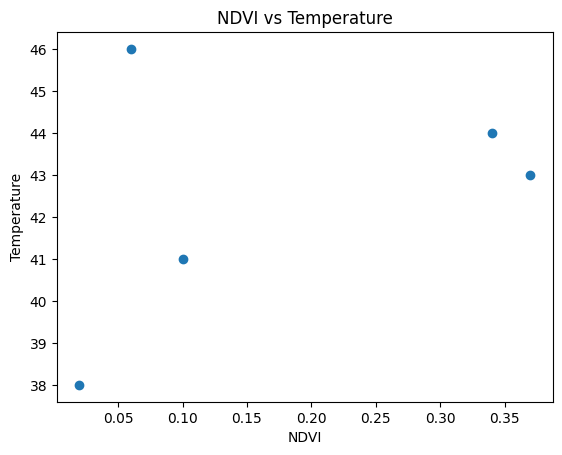

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["NDVI"], df["Temperature"])
plt.xlabel("NDVI")
plt.ylabel("Temperature")
plt.title("NDVI vs Temperature")

plt.savefig("graphs/ndvi_vs_temp.png", dpi=300, bbox_inches="tight")
plt.show()

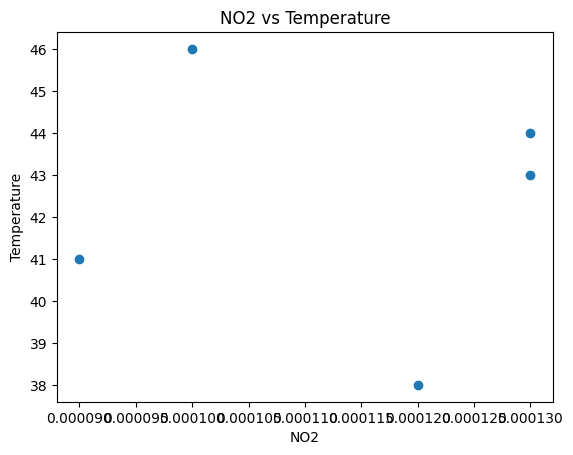

In [23]:
plt.figure()
plt.scatter(df["NO2"], df["Temperature"])
plt.xlabel("NO2")
plt.ylabel("Temperature")
plt.title("NO2 vs Temperature")

plt.savefig("graphs/no2_vs_temp.png", dpi=300, bbox_inches="tight")
plt.show()

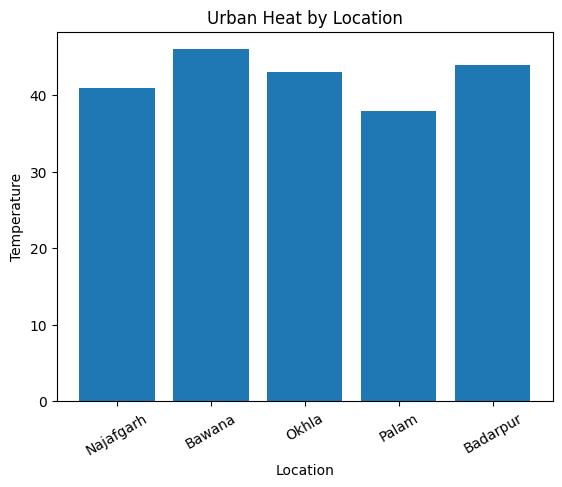

In [24]:
plt.figure()
plt.bar(df["Location"], df["Temperature"])
plt.xlabel("Location")
plt.ylabel("Temperature")
plt.title("Urban Heat by Location")
plt.xticks(rotation=30)

plt.savefig("graphs/temp_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
plt.savefig("graphs/ah_2010_vs_2050.png")

<Figure size 640x480 with 0 Axes>

In [26]:
print(df.head())
print(df.head())

    Location  NDVI      NO2  Temperature
0  Najafgarh  0.10  0.00009           41
1     Bawana  0.06  0.00010           46
2      Okhla  0.37  0.00013           43
3      Palam  0.02  0.00012           38
4   Badarpur  0.34  0.00013           44
    Location  NDVI      NO2  Temperature
0  Najafgarh  0.10  0.00009           41
1     Bawana  0.06  0.00010           46
2      Okhla  0.37  0.00013           43
3      Palam  0.02  0.00012           38
4   Badarpur  0.34  0.00013           44


In [27]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



In [28]:
def load_tif(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        data = np.where(data == src.nodata, np.nan, data)
    return data

In [29]:
AH_2010_year = load_tif("data/AHE_2010_year.tif")
AH_2050_year = load_tif("data/AHE_2050_year.tif")

df_ah_2010 = pd.DataFrame({"AH": AH_2010_year.flatten()})
df_ah_2050 = pd.DataFrame({"AH": AH_2050_year.flatten()})

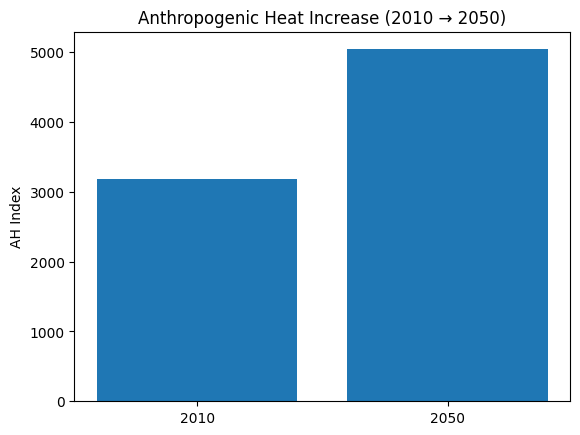

In [30]:
import matplotlib.pyplot as plt

plt.figure()

vals = [
    np.nanmean(df_ah_2010["AH"]),
    np.nanmean(df_ah_2050["AH"])
]

plt.bar(["2010", "2050"], vals)

plt.title("Anthropogenic Heat Increase (2010 → 2050)")
plt.ylabel("AH Index")

plt.savefig("graphs/ah_2010_vs_2050.png", dpi=300, bbox_inches="tight")
plt.show()